# car_prediction Dataset
From data to pridiction: Car price prediction using ML(Linear Regression and Random forest)
#Data set  Overview
this data set  contains information about different cars and their selling prices
#Features 
#Objective
#Data preprocessing
#Model building
#Model evaluation

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv("E:\\car data_codealpha.csv")
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [5]:
df.shape

(301, 9)

In [6]:
df.columns

Index(['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Driven_kms',
       'Fuel_Type', 'Selling_type', 'Transmission', 'Owner'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Selling_type   301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [8]:
df.describe()

,Year,Selling_Price,Present_Price,Driven_kms,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.642584,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [9]:
# CHECK MISSING VALUES

df.isnull().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64

In [11]:
# IF MISSING VALUES OCCURS
df=df.dropna()
df

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0
...,...,...,...,...,...,...,...,...,...
296,city,2016,9.50,11.60,33988,Diesel,Dealer,Manual,0
297,brio,2015,4.00,5.90,60000,Petrol,Dealer,Manual,0
298,city,2009,3.35,11.00,87934,Petrol,Dealer,Manual,0
299,city,2017,11.50,12.50,9000,Diesel,Dealer,Manual,0


In [14]:
# Categorical Data Handle like Fuel_type,Seller_type,Transmission then we have to convert in numbers

df= pd.get_dummies(df,drop_first=True)
df

,Year,Selling_Price,Present_Price,Driven_kms,Owner,Car_Name_Activa 3g,Car_Name_Activa 4g,Car_Name_Bajaj ct 100,Car_Name_Bajaj Avenger 150,Car_Name_Bajaj Avenger 150 street,...,Car_Name_swift,Car_Name_sx4,Car_Name_verna,Car_Name_vitara brezza,Car_Name_wagon r,Car_Name_xcent,Fuel_Type_Diesel,Fuel_Type_Petrol,Selling_type_Individual,Transmission_Manual
0,2014,3.35,5.59,27000,0,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,True
1,2013,4.75,9.54,43000,0,False,False,False,False,False,...,False,True,False,False,False,False,True,False,False,True
2,2017,7.25,9.85,6900,0,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,True
3,2011,2.85,4.15,5200,0,False,False,False,False,False,...,False,False,False,False,True,False,False,True,False,True
4,2014,4.60,6.87,42450,0,False,False,False,False,False,...,True,False,False,False,False,False,True,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
296,2016,9.50,11.60,33988,0,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,True
297,2015,4.00,5.90,60000,0,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,True
298,2009,3.35,11.00,87934,0,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,True
299,2017,11.50,12.50,9000,0,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,True


In [15]:
# Features (X) AND TARGET(y) where we have Target =price(usually Selling_price)

X=df.drop("Selling_Price",axis=1)
y=df["Selling_Price"]


In [17]:
# now Train -test split
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [21]:
# Now model training (Linear Regression)

from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(X_train,y_train)
print(model)

LinearRegression()


In [20]:
# PREDICTION 

y_pred = model.predict(X_test)
print(y_pred)

[ 7.47327051  9.58880632  5.56883578 -0.40941815  8.55896043  6.88890857
  1.47635719  6.23695329  0.98014478  6.68925428 15.63172868  0.29557627
  7.97759508  8.08373758  6.19289061  2.70151483  2.72386344 10.98923224
  7.77090451  8.56271721  5.55477855  7.63455899  5.6498586   1.89746929
  6.25342368  3.48912822  5.48662283  1.6085983   2.6805568   2.67421952
 -0.03307212  9.11656913 -2.33116821  1.98326133  8.36119393  3.98900218
  6.09888859  6.17398282  4.27677317  6.74710603  5.51688689  8.34755944
  3.67455712  0.25706045 13.06489129  0.04497286  8.34319661  9.55198302
  3.90152259  4.03845455  5.9287072   2.70075543 22.92984367 20.60225579
  7.30522747  9.84045173  4.59171221  8.91665681  0.05897455  6.62617599
  3.66819743]


In [22]:
# Evaluation

from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

print("MAE",mean_absolute_error(y_test,y_pred))
print("MSE",mean_squared_error(y_test,y_pred))
print("R2 Score",r2_score(y_test,y_pred))

MAE 2.0365174789922245
MSE 9.221090391457379
R2 Score 0.5997023481937156


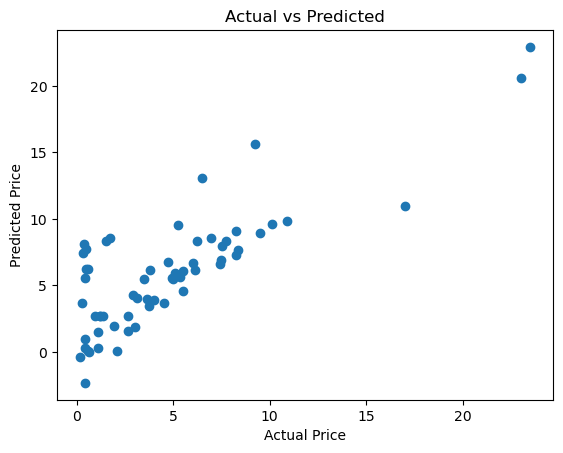

In [25]:
# SIMPLE VISUALIZATION
plt.scatter(y_test,y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted")
plt.show()

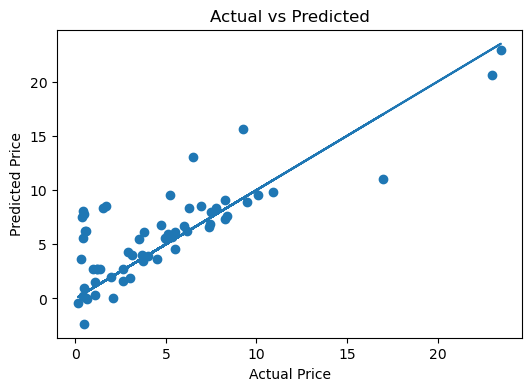

In [26]:
# Graph (Line + scatter)
plt.figure(figsize=(6,4))
plt.scatter(y_test,y_pred)
plt.plot(y_test,y_test)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted")
plt.show()

In [30]:
#make our model more powerful by using random forest regression

from sklearn.ensemble import RandomForestRegressor

rf_model= RandomForestRegressor()
rf_model.fit(X_train,y_train)
y_pred_rf=rf_model.predict(X_test)

print(rf_model)
print(y_pred_rf)

RandomForestRegressor()
[ 0.4202 10.1654  4.976   0.2083  7.4358  6.543   1.1067  0.5673  0.4681
  6.8585  7.9096  1.1068  8.3696  0.472   5.434   2.5555  1.103  14.0031
  0.4803  1.557   0.3411  7.791   4.8035  2.6695  0.4972  3.432   5.214
  3.153   1.1722  1.1688  0.4254  8.8042  0.4683  2.6035  7.6812  4.138
  6.3415  5.9299  2.5585  6.3248  5.262   3.6824  4.9315  0.5548  6.2935
  0.7144  8.1585  6.7465  2.8615  3.5075  5.1325  1.4702 22.5969 20.42
  6.17    9.9729  5.077   8.6101  2.835   6.6564  0.2324]


In [31]:
# Now compare evalution 

from sklearn.metrics import r2_score

print("Linear Regression R2:",r2_score(y_test,y_pred))
print("Random Forest R2:",r2_score(y_test,y_pred_rf))

Linear Regression R2: 0.5997023481937156
Random Forest R2: 0.9614968085768941


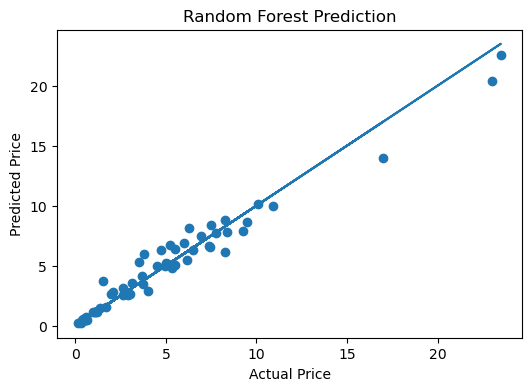

In [32]:
#NEW GRAPH FOR Random forest

plt.figure(figsize=(6,4))
plt.scatter(y_test,y_pred_rf)
plt.plot(y_test,y_test)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Random Forest Prediction")
plt.show()


In [41]:
# now feature importance (states that which feature effects on the price most)
importance =rf_model.feature_importances_
feature_name=X.columns


feature_imp= pd.DataFrame({
        "Feature":feature_name,
        "Importance":importance
})
feature_imp =feature_imp.sort_values(by="Importance",ascending=False)
top_features=feature_imp.head(10)
print(feature_imp)

                        Feature  Importance
1                 Present_Price    0.884510
0                          Year    0.049968
2                    Driven_kms    0.034176
104         Transmission_Manual    0.004079
89              Car_Name_innova    0.003567
..                          ...         ...
98       Car_Name_vitara brezza    0.000000
5            Car_Name_Activa 4g    0.000000
33    Car_Name_Honda Activa 125    0.000000
41   Car_Name_Honda Dream Yuga     0.000000
73             Car_Name_corolla    0.000000

[105 rows x 2 columns]
